# Spatio-Temporal AutoEncoder com Dropout no dataset UCSDPed2
Artigo: https://dl.acm.org/doi/10.1145/3123266.3123451

# Importação das bibliotecas

In [2]:
import glob
import os
import random
import re

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from IPython.display import HTML
from matplotlib import animation
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

# Configuração

In [3]:
# Define as sementes, os caminhos do dataset e os hiperparâmetros
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

kaggle_dataset_directory = (
    '/kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/'
    'UCSD_Anomaly_Dataset.v1p2/UCSDped2'
)

base_directory = kaggle_dataset_directory
train_directory = os.path.join(base_directory, 'Train')
test_directory = os.path.join(base_directory, 'Test')
ground_truth_path = os.path.join(test_directory, 'UCSDped2.m')

validation_video_names = ['Train014', 'Train015', 'Train016']

window_size = 16
prediction_size = 16
image_width = 128
image_height = 128
batch_size = 8
num_epochs = 30
threshold_percentile = 95

print('Pasta base:', base_directory)
print('Treino:', train_directory)
print('Teste:', test_directory)
print('Ground truth:', ground_truth_path)
print('Vídeos fixos de validação:', validation_video_names)

Pasta base: /kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2
Treino: /kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Train
Teste: /kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test
Ground truth: /kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/UCSDped2.m
Vídeos fixos de validação: ['Train014', 'Train015', 'Train016']


# Pré-processamento

In [4]:
# Define as operações básicas de redimensionamento e normalização dos frames
def resize_frame(frame, width=128, height=128):
    if len(frame.shape) == 3:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return cv2.resize(frame, (width, height), interpolation=cv2.INTER_AREA)

def normalize_channel(frame):
    normalized_frame = frame.astype(np.float32) / 255.0
    return np.expand_dims(normalized_frame, axis=-1)

In [5]:
# Define o carregamento dos vídeos e a criação das janelas temporais
def get_video_directories(dataset_directory, prefix):
    video_directories = []
    directory_pattern = re.compile(rf'^{prefix}\d+$')

    for directory_name in sorted(os.listdir(dataset_directory)):
        directory_path = os.path.join(dataset_directory, directory_name)
        if (os.path.isdir(directory_path) and directory_pattern.match(directory_name)):
            video_directories.append(directory_path)

    return video_directories

def get_frame_paths(video_directory):
    return sorted(glob.glob(os.path.join(video_directory, '*.tif')))

def preprocess_frame(frame_path):
    frame = cv2.imread(frame_path, cv2.IMREAD_GRAYSCALE)
    frame = resize_frame(frame, width=image_width, height=image_height)
    return normalize_channel(frame).astype(np.float32)

def load_video(video_directory):
    frame_paths = get_frame_paths(video_directory)
    if not frame_paths:
        raise ValueError(f'No .tif frames found in: {video_directory}')

    frames = [preprocess_frame(frame_path) for frame_path in frame_paths]
    return np.asarray(frames, dtype=np.float32)

def create_windows(video, window_size=16, prediction_size=16):
    input_windows = []
    reconstruction_targets = []
    prediction_targets = []
    last_input_frame_indices = []

    total_window_size = window_size + prediction_size
    for start_index in range(len(video) - total_window_size + 1):
        input_window = video[start_index:start_index + window_size]
        future_window = video[start_index + window_size:start_index + total_window_size]

        input_windows.append(input_window)
        reconstruction_targets.append(input_window)
        prediction_targets.append(future_window)
        last_input_frame_indices.append(start_index + window_size - 1)

    return (
        np.asarray(input_windows, dtype=np.float32),
        np.asarray(reconstruction_targets, dtype=np.float32),
        np.asarray(prediction_targets, dtype=np.float32),
        np.asarray(last_input_frame_indices, dtype=np.int32)
    )

In [6]:
# Lista os vídeos e aplica a divisão fixa entre treino, validação e teste
all_training_videos = get_video_directories(train_directory, 'Train')
test_videos = get_video_directories(test_directory, 'Test')

validation_videos = [
    video_directory
    for video_directory in all_training_videos
    if os.path.basename(video_directory) in validation_video_names
]
training_videos = [
    video_directory
    for video_directory in all_training_videos
    if os.path.basename(video_directory) not in validation_video_names
]

if len(validation_videos) != len(validation_video_names):
    found_video_names = [os.path.basename(video_directory) for video_directory in validation_videos]
    raise ValueError(
        'Vídeos de validação não encontrados. '
        f'Esperados: {validation_video_names}. '
        f'Encontrados: {found_video_names}'
    )

print('Vídeos normais disponíveis:', len(all_training_videos))
print(
    'Vídeos de treino:',
    len(training_videos),
    [os.path.basename(video_directory) for video_directory in training_videos]
)
print(
    'Vídeos de validação:',
    len(validation_videos),
    [os.path.basename(video_directory) for video_directory in validation_videos]
)
print('Vídeos de teste:', len(test_videos))
print('Frames no primeiro vídeo de treino:', len(get_frame_paths(training_videos[0])))
print('Frames no primeiro vídeo de validação:', len(get_frame_paths(validation_videos[0])))
print('Frames no primeiro vídeo de teste:', len(get_frame_paths(test_videos[0])))

Vídeos normais disponíveis: 16
Vídeos de treino: 13 ['Train001', 'Train002', 'Train003', 'Train004', 'Train005', 'Train006', 'Train007', 'Train008', 'Train009', 'Train010', 'Train011', 'Train012', 'Train013']
Vídeos de validação: 3 ['Train014', 'Train015', 'Train016']
Vídeos de teste: 12
Frames no primeiro vídeo de treino: 120
Frames no primeiro vídeo de validação: 150
Frames no primeiro vídeo de teste: 180


In [7]:
# Carrega as janelas e aplica uma permutação fixa ao conjunto de treino
def load_windows(video_directories):
    input_windows = []
    reconstruction_targets = []
    prediction_targets = []

    for video_directory in video_directories:
        video = load_video(video_directory)
        inputs, reconstruction, prediction, _ = create_windows(video, window_size, prediction_size)

        input_windows.append(inputs)
        reconstruction_targets.append(reconstruction)
        prediction_targets.append(prediction)

    return (
        np.concatenate(input_windows, axis=0),
        np.concatenate(reconstruction_targets, axis=0),
        np.concatenate(prediction_targets, axis=0)
    )

x_train, y_reconstruction_train, y_prediction_train = load_windows(training_videos)
x_validation, y_reconstruction_validation, y_prediction_validation = (
    load_windows(validation_videos)
)

training_order = np.random.default_rng(SEED).permutation(len(x_train))
x_train = x_train[training_order]
y_reconstruction_train = y_reconstruction_train[training_order]
y_prediction_train = y_prediction_train[training_order]

print('Entradas de treino:', x_train.shape)
print('Alvo de reconstrução - treino:', y_reconstruction_train.shape)
print('Alvo de predição - treino:', y_prediction_train.shape)
print('Entradas de validação:', x_validation.shape)
print('Alvo de reconstrução - validação:', y_reconstruction_validation.shape)
print('Alvo de predição - validação:', y_prediction_validation.shape)
print('Permutação fixa do treino - seed:', SEED)
print('Primeiros índices da permutação:', training_order[:10])

Entradas de treino: (1697, 16, 128, 128, 1)
Alvo de reconstrução - treino: (1697, 16, 128, 128, 1)
Alvo de predição - treino: (1697, 16, 128, 128, 1)
Entradas de validação: (357, 16, 128, 128, 1)
Alvo de reconstrução - validação: (357, 16, 128, 128, 1)
Alvo de predição - validação: (357, 16, 128, 128, 1)
Permutação fixa do treino - seed: 42
Primeiros índices da permutação: [ 352  911  818 1216  304  282 1615  476  505 1590]


# Anotações do conjunto de teste

In [8]:
# Converte as anotações do dataset em rótulos binários por frame
def parse_ground_truth(file_path):
    with open(file_path, 'r', encoding='utf-8') as ground_truth_file:
        annotation_text = ground_truth_file.read()

    interval_matches = re.findall(r'gt_frame\s*=\s*\[(.*?)\]', annotation_text)
    annotations = []

    for interval_match in interval_matches:
        anomaly_frames = []
        frame_tokens = interval_match.split(',')

        for frame_token in frame_tokens:
            frame_token = frame_token.strip()
            if ':' in frame_token:
                start_frame, end_frame = frame_token.split(':')
                anomaly_frames.extend(range(int(start_frame), int(end_frame) + 1))
            elif frame_token:
                anomaly_frames.append(int(frame_token))

        annotations.append(sorted(set(anomaly_frames)))

    return annotations

def create_frame_labels(video_directory, anomaly_frames):
    frame_count = len(get_frame_paths(video_directory))
    labels = np.zeros(frame_count, dtype=np.uint8)

    for frame_number in anomaly_frames:
        frame_index = frame_number - 1
        if 0 <= frame_index < frame_count:
            labels[frame_index] = 1

    return labels

ground_truth_annotations = parse_ground_truth(ground_truth_path)
print('Vídeos anotados:', len(ground_truth_annotations))
print('Primeira anotação:', ground_truth_annotations[0][:10], '...')

Vídeos anotados: 12
Primeira anotação: [61, 62, 63, 64, 65, 66, 67, 68, 69, 70] ...


# Visualização dos dados

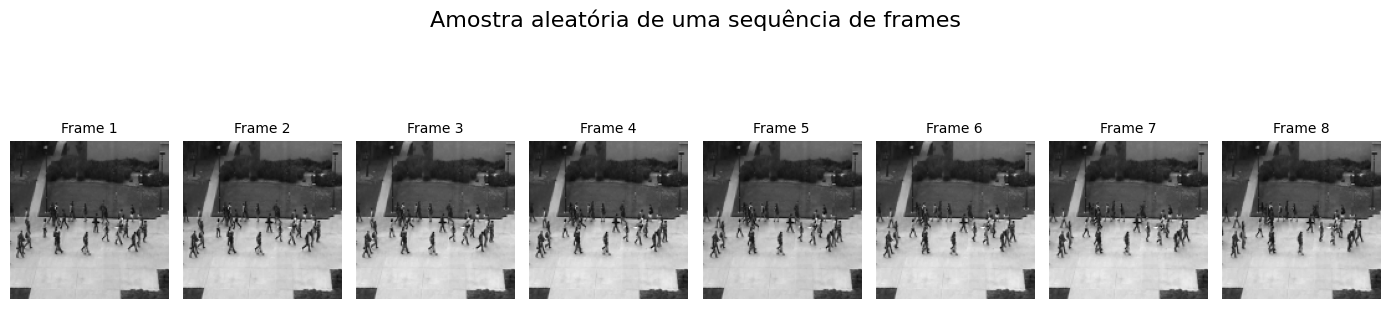

In [9]:
# Exibe uma amostra aleatória das janelas usadas no treinamento
def show_random_sequence(data, frame_count=8):
    sequence_index = random.randint(0, len(data) - 1)
    sequence = data[sequence_index]

    plt.figure(figsize=(14, 4))
    plt.suptitle('Amostra aleatória de uma sequência de frames', fontsize=16)

    displayed_frame_count = min(frame_count, len(sequence))
    for frame_index in range(displayed_frame_count):
        plt.subplot(1, displayed_frame_count, frame_index + 1)
        plt.imshow(sequence[frame_index, :, :, 0], cmap='gray')
        plt.title(f'Frame {frame_index + 1}', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_random_sequence(x_train)

# Aplicação da técnica de regularização

In [10]:
# Define a taxa de Spatial Dropout 3D aplicada ao bottleneck
dropout_rate = 0.3

print('Taxa de Dropout:', dropout_rate)

Taxa de Dropout: 0.3


# Modelo proposto

In [11]:
# Define as losses, a arquitetura STAE e a compilação do modelo
def reconstruction_loss(y_true, y_pred):
    squared_error = tf.square(y_true - y_pred)
    per_sample_loss = tf.reduce_sum(squared_error, axis=[1, 2, 3, 4])
    clip_volume = tf.cast(tf.reduce_prod(tf.shape(y_true)[1:]), tf.float32)
    return tf.reduce_mean(per_sample_loss / clip_volume)

def weighted_prediction_loss(sequence_length=16):
    weight_values = [
        float(sequence_length - time_index)
        for time_index in range(1, sequence_length + 1)
    ]
    temporal_weights = tf.reshape(
        tf.constant(weight_values, dtype=tf.float32),
        (1, sequence_length, 1, 1, 1)
    )
    temporal_scale = 1.0 / (sequence_length ** 2)

    def loss(y_true, y_pred):
        squared_error = tf.square(y_true - y_pred)
        weighted_error = squared_error * temporal_weights
        per_sample_loss = tf.reduce_sum(weighted_error, axis=[1, 2, 3, 4])
        clip_volume = tf.cast(tf.reduce_prod(tf.shape(y_true)[1:]), tf.float32)
        return temporal_scale * tf.reduce_mean(per_sample_loss / clip_volume)

    return loss

def build_model():
    def conv3d_layer(inputs, num_filters, is_last=False):
        output = tf.keras.layers.Conv3D(
            filters=num_filters,
            kernel_size=(3, 3, 3),
            strides=(1, 1, 1),
            padding='same',
            use_bias=False
        )(inputs)
        output = tf.keras.layers.BatchNormalization()(output)
        output = tf.keras.layers.LeakyReLU(negative_slope=0.1)(output)
        if not is_last:
            output = tf.keras.layers.MaxPooling3D(
                pool_size=(2, 2, 2),
                strides=(2, 2, 2),
                padding='same'
            )(output)
        return output

    def deconv3d_layer(inputs, num_filters):
        output = tf.keras.layers.Conv3DTranspose(
            filters=num_filters,
            kernel_size=(3, 3, 3),
            strides=(2, 2, 2),
            padding='same',
            use_bias=False
        )(inputs)
        output = tf.keras.layers.BatchNormalization()(output)
        return tf.keras.layers.LeakyReLU(negative_slope=0.1)(output)

    def output_layer(inputs, num_filters):
        return tf.keras.layers.Conv3D(
            filters=num_filters,
            kernel_size=(3, 3, 3),
            strides=(1, 1, 1),
            padding='same',
            use_bias=True,
            activation='sigmoid'
        )(inputs)

    inputs = tf.keras.layers.Input(
        shape=(window_size, image_height, image_width, 1),
        name='input_window'
    )

    # Encoder
    encoded = conv3d_layer(inputs, num_filters=32)
    encoded = conv3d_layer(encoded, num_filters=48)
    encoded = conv3d_layer(encoded, num_filters=64)
    encoded = conv3d_layer(encoded, num_filters=64, is_last=True)
    encoded = tf.keras.layers.SpatialDropout3D(
        rate=dropout_rate
    )(encoded)
    print(f'Shape do bottleneck: {encoded.shape}. ' 'Deve ser (2,16,16,64)')

    # Decoder de reconstrução
    reconstruction = deconv3d_layer(encoded, num_filters=48)
    reconstruction = deconv3d_layer(reconstruction, num_filters=32)
    reconstruction = deconv3d_layer(reconstruction, num_filters=32)
    reconstruction = output_layer(reconstruction, num_filters=1)
    print(f'Shape da saída da reconstrução: {reconstruction.shape}. ' 'Deve ser (16,128,128,1)')

    # Decoder de predição dos próximos frames
    prediction = deconv3d_layer(encoded, num_filters=48)
    prediction = deconv3d_layer(prediction, num_filters=32)
    prediction = deconv3d_layer(prediction, num_filters=32)
    prediction = output_layer(prediction, num_filters=1)
    print(f'Shape da predição dos frames seguintes: {prediction.shape}. ' 'Deve ser (16,128,128,1)')

    model = tf.keras.Model(inputs=inputs, outputs=[reconstruction, prediction])
    prediction_loss = weighted_prediction_loss(sequence_length=window_size)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=[reconstruction_loss, prediction_loss],
        loss_weights=[1.0, 1.0]
    )
    return model

model = build_model()
model.summary()

I0000 00:00:1783278403.903109      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783278403.906085      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Shape do bottleneck: (None, 2, 16, 16, 64). Deve ser (2,16,16,64)
Shape da saída da reconstrução: (None, 16, 128, 128, 1). Deve ser (16,128,128,1)
Shape da predição dos frames seguintes: (None, 16, 128, 128, 1). Deve ser (16,128,128,1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_window        │ (None, 16, 128,   │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 16, 128,   │        864 │ input_window[0][… │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 128,   │        128 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 16, 128,   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 8, 64, 64, │          0 │ leaky_re_lu[0][0] │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 8, 64, 64, │     41,472 │ max_pooling3d[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        192 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 4, 32, 32, │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling3D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 4, 32, 32, │     82,944 │ max_pooling3d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 32, 32, │        256 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 4, 32, 32, │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 2, 16, 16, │          0 │ leaky_re_lu_2[0]… │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 2, 16, 16, │    110,592 │ max_pooling3d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 16, 16, │        256 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 2, 16, 16, │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d   │ (None, 2, 16, 16, │          0 │ leaky_re_lu_3[0]

 Total params: 543,458 (2.07 MB)

 Trainable params: 542,594 (2.07 MB)

 Non-trainable params: 864 (3.38 KB)

# Treinamento

In [12]:
# Confere os vídeos e os shapes usados em cada partição do experimento
print('Divisão fixa por vídeo')
print('Treino:', [os.path.basename(video_directory) for video_directory in training_videos])
print('Validação:', [os.path.basename(video_directory) for video_directory in validation_videos])
print('Teste:', [os.path.basename(video_directory) for video_directory in test_videos])
print('Shape de treino:', x_train.shape)
print('Shape de validação:', x_validation.shape)

Divisão fixa por vídeo
Treino: ['Train001', 'Train002', 'Train003', 'Train004', 'Train005', 'Train006', 'Train007', 'Train008', 'Train009', 'Train010', 'Train011', 'Train012', 'Train013']
Validação: ['Train014', 'Train015', 'Train016']
Teste: ['Test001', 'Test002', 'Test003', 'Test004', 'Test005', 'Test006', 'Test007', 'Test008', 'Test009', 'Test010', 'Test011', 'Test012']
Shape de treino: (1697, 16, 128, 128, 1)
Shape de validação: (357, 16, 128, 128, 1)


In [13]:
# Treina o modelo com ordem fixa e validação separada por vídeo
history = model.fit(
    x_train,
    [y_reconstruction_train, y_prediction_train],
    validation_data=(
        x_validation,
        [y_reconstruction_validation, y_prediction_validation]
    ),
    epochs=num_epochs,
    batch_size=batch_size,
    shuffle=False,
    verbose=1
)

Epoch 1/30


I0000 00:00:1783278451.340486     139 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


213/213 ━━━━━━━━━━━━━━━━━━━━ 101s 373ms/step - conv3d_4_loss: 0.0109 - conv3d_5_loss: 3.3112e-04 - loss: 0.0113 - val_conv3d_4_loss: 0.0306 - val_conv3d_5_loss: 0.0010 - val_loss: 0.0316
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 72s 336ms/step - conv3d_4_loss: 0.0031 - conv3d_5_loss: 1.1253e-04 - loss: 0.0032 - val_conv3d_4_loss: 0.0102 - val_conv3d_5_loss: 3.4089e-04 - val_loss: 0.0106
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 71s 335ms/step - conv3d_4_loss: 0.0024 - conv3d_5_loss: 9.2390e-05 - loss: 0.0025 - val_conv3d_4_loss: 0.0023 - val_conv3d_5_loss: 7.5333e-05 - val_loss: 0.0024
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 71s 335ms/step - conv3d_4_loss: 0.0021 - conv3d_5_loss: 8.1926e-05 - loss: 0.0022 - val_conv3d_4_loss: 0.0017 - val_conv3d_5_loss: 6.2086e-05 - val_loss: 0.0018
Epoch 5/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 72s 336ms/step - conv3d_4_loss: 0.0019 - conv3d_5_loss: 7.4407e-05 - loss: 0.0020 - val_conv3d_4_loss: 0.0015 - val_conv3d_5_loss: 5.7501e-05 - val_loss: 0.0016
Epoch 6/3

# Visualização da reconstrução

In [14]:
# Define uma animação para comparar sequências reais e geradas pelo modelo
def display_sequence_comparison(original, generated, generated_title='Modelo', sample_index=0):
    # Garante o intervalo esperado pelo Matplotlib
    original = np.clip(original, 0, 1)
    generated = np.clip(generated, 0, 1)

    # Remove o canal unitário das sequências em escala de cinza
    if original.shape[-1] == 1:
        original = np.squeeze(original, axis=-1)
        generated = np.squeeze(generated, axis=-1)
        color_map = 'gray'
    else:
        color_map = None

    frame_count = original.shape[0]
    figure, (original_axis, generated_axis) = plt.subplots(1, 2, figsize=(10, 5))
    figure.suptitle(f'Análise de sequência - índice: {sample_index}', fontsize=12)

    original_axis.set_title('Original real')
    generated_axis.set_title(generated_title)
    original_axis.axis('off')
    generated_axis.axis('off')

    original_image = original_axis.imshow(original[0], cmap=color_map)
    generated_image = generated_axis.imshow(generated[0], cmap=color_map)
    plt.tight_layout()

    # Atualiza os dois painéis com o frame correspondente
    def update(frame_index):
        original_image.set_data(original[frame_index])
        generated_image.set_data(generated[frame_index])
        return [original_image, generated_image]

    frame_animation = animation.FuncAnimation(
        figure,
        update,
        frames=frame_count,
        interval=150,
        blit=True
    )

    plt.close()
    return HTML(frame_animation.to_html5_video())

In [15]:
# Reconstrói uma sequência aleatória do conjunto de validação
sample_index = np.random.randint(0, len(x_validation))
input_batch = x_validation[sample_index:sample_index + 1]

model_outputs = model.predict(input_batch)
reconstructed_sequence = model_outputs[0][0]
predicted_sequence = model_outputs[1][0]

display_sequence_comparison(
    original=x_validation[sample_index],
    generated=reconstructed_sequence,
    generated_title='Reconstrução',
    sample_index=sample_index
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step


In [16]:
# Compara os frames futuros reais com a predição da mesma sequência
display_sequence_comparison(
    original=y_prediction_validation[sample_index],
    generated=predicted_sequence,
    generated_title='Predição futura',
    sample_index=sample_index
)

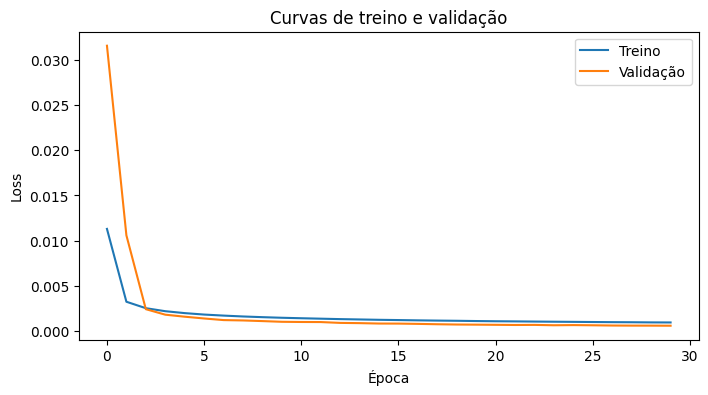

In [18]:
# Plota as curvas de loss de treino e validação ao longo das épocas
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curvas de treino e validação')
plt.legend()
plt.show()

# Avaliação

In [19]:
# Define o cálculo do score de anomalia a partir da reconstrução por frame
def normalize_scores(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

def create_reconstruction_windows(video, window_size=16):
    if len(video) < window_size:
        raise ValueError(f'O vídeo deve conter pelo menos {window_size} frames.')

    windows = []
    start_indices = []

    for start_index in range(len(video) - window_size + 1):
        windows.append(video[start_index:start_index + window_size])
        start_indices.append(start_index)

    return (np.asarray(windows, dtype=np.float32), np.asarray(start_indices, dtype=np.int32))

def compute_anomaly_scores(video_directory):
    video = load_video(video_directory)
    input_windows, start_indices = create_reconstruction_windows(video, window_size)

    reconstructed_windows, _ = model.predict(input_windows, batch_size=batch_size, verbose=0)
    reconstruction_errors = np.mean((reconstructed_windows - input_windows) ** 2, axis=(2, 3, 4))

    accumulated_scores = np.zeros(len(video), dtype=np.float32)
    reconstruction_counts = np.zeros(len(video), dtype=np.float32)

    for start_index, frame_errors in zip(start_indices, reconstruction_errors):
        stop_index = start_index + window_size
        accumulated_scores[start_index:stop_index] += frame_errors
        reconstruction_counts[start_index:stop_index] += 1

    if np.any(reconstruction_counts == 0):
        raise RuntimeError('Alguns frames não possuem score de reconstrução.')

    return accumulated_scores / reconstruction_counts

In [20]:
# Avalia todos os vídeos e calcula as métricas globais
validation_normalized_scores = []
validation_reconstruction_errors = []

for video_directory in validation_videos:
    reconstruction_errors = compute_anomaly_scores(video_directory)
    normalized_scores = normalize_scores(reconstruction_errors)
    validation_reconstruction_errors.extend(reconstruction_errors)
    validation_normalized_scores.extend(normalized_scores)

validation_reconstruction_errors = np.asarray(validation_reconstruction_errors, dtype=np.float32)
validation_normalized_scores = np.asarray(validation_normalized_scores, dtype=np.float32)
classification_threshold = np.percentile(validation_normalized_scores, threshold_percentile)

ground_truth_labels = []
normalized_test_scores = []
video_results = []

for video_directory, anomaly_frames in zip(test_videos, ground_truth_annotations):
    frame_labels = create_frame_labels(video_directory, anomaly_frames)
    reconstruction_errors = compute_anomaly_scores(video_directory)
    normalized_scores = normalize_scores(reconstruction_errors)

    ground_truth_labels.extend(frame_labels)
    normalized_test_scores.extend(normalized_scores)
    video_results.append({
        'name': os.path.basename(video_directory),
        'labels': frame_labels,
        'normalized_scores': normalized_scores,
        'reconstruction_errors': reconstruction_errors
    })

ground_truth_labels = np.asarray(ground_truth_labels)
normalized_test_scores = np.asarray(normalized_test_scores, dtype=np.float32)
predicted_test_labels = (normalized_test_scores >= classification_threshold).astype(np.uint8)

auroc = roc_auc_score(ground_truth_labels, normalized_test_scores)

false_positive_rates, true_positive_rates, roc_thresholds = roc_curve(
    ground_truth_labels,
    normalized_test_scores
)
false_negative_rates = 1 - true_positive_rates
eer_index = np.nanargmin(np.abs(false_positive_rates - false_negative_rates))
eer = (false_positive_rates[eer_index] + false_negative_rates[eer_index]) / 2
eer_threshold = roc_thresholds[eer_index]

auprc = average_precision_score(ground_truth_labels, normalized_test_scores)
precision = precision_score(ground_truth_labels, predicted_test_labels, zero_division=0)
recall = recall_score(ground_truth_labels, predicted_test_labels, zero_division=0)
f1 = f1_score(ground_truth_labels, predicted_test_labels, zero_division=0)
accuracy = accuracy_score(ground_truth_labels, predicted_test_labels)

print('Percentil do threshold de validação:', threshold_percentile)
print('Threshold de classificação:', classification_threshold)
print('AUROC:', auroc)
print('EER:', eer)
print('Threshold do EER:', eer_threshold)
print('AUPRC:', auprc)
print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)
print('Accuracy:', accuracy)

Percentil do threshold de validação: 95
Threshold de classificação: 0.79990876
AUROC: 0.8045052097301936
EER: 0.26899003647481623
Threshold do EER: 0.3305519
AUPRC: 0.9497917267508906
Precision: 0.987603305785124
Recall: 0.14502427184466019
F1-score: 0.2529100529100529
Accuracy: 0.2975124378109453


# Visualização dos resultados

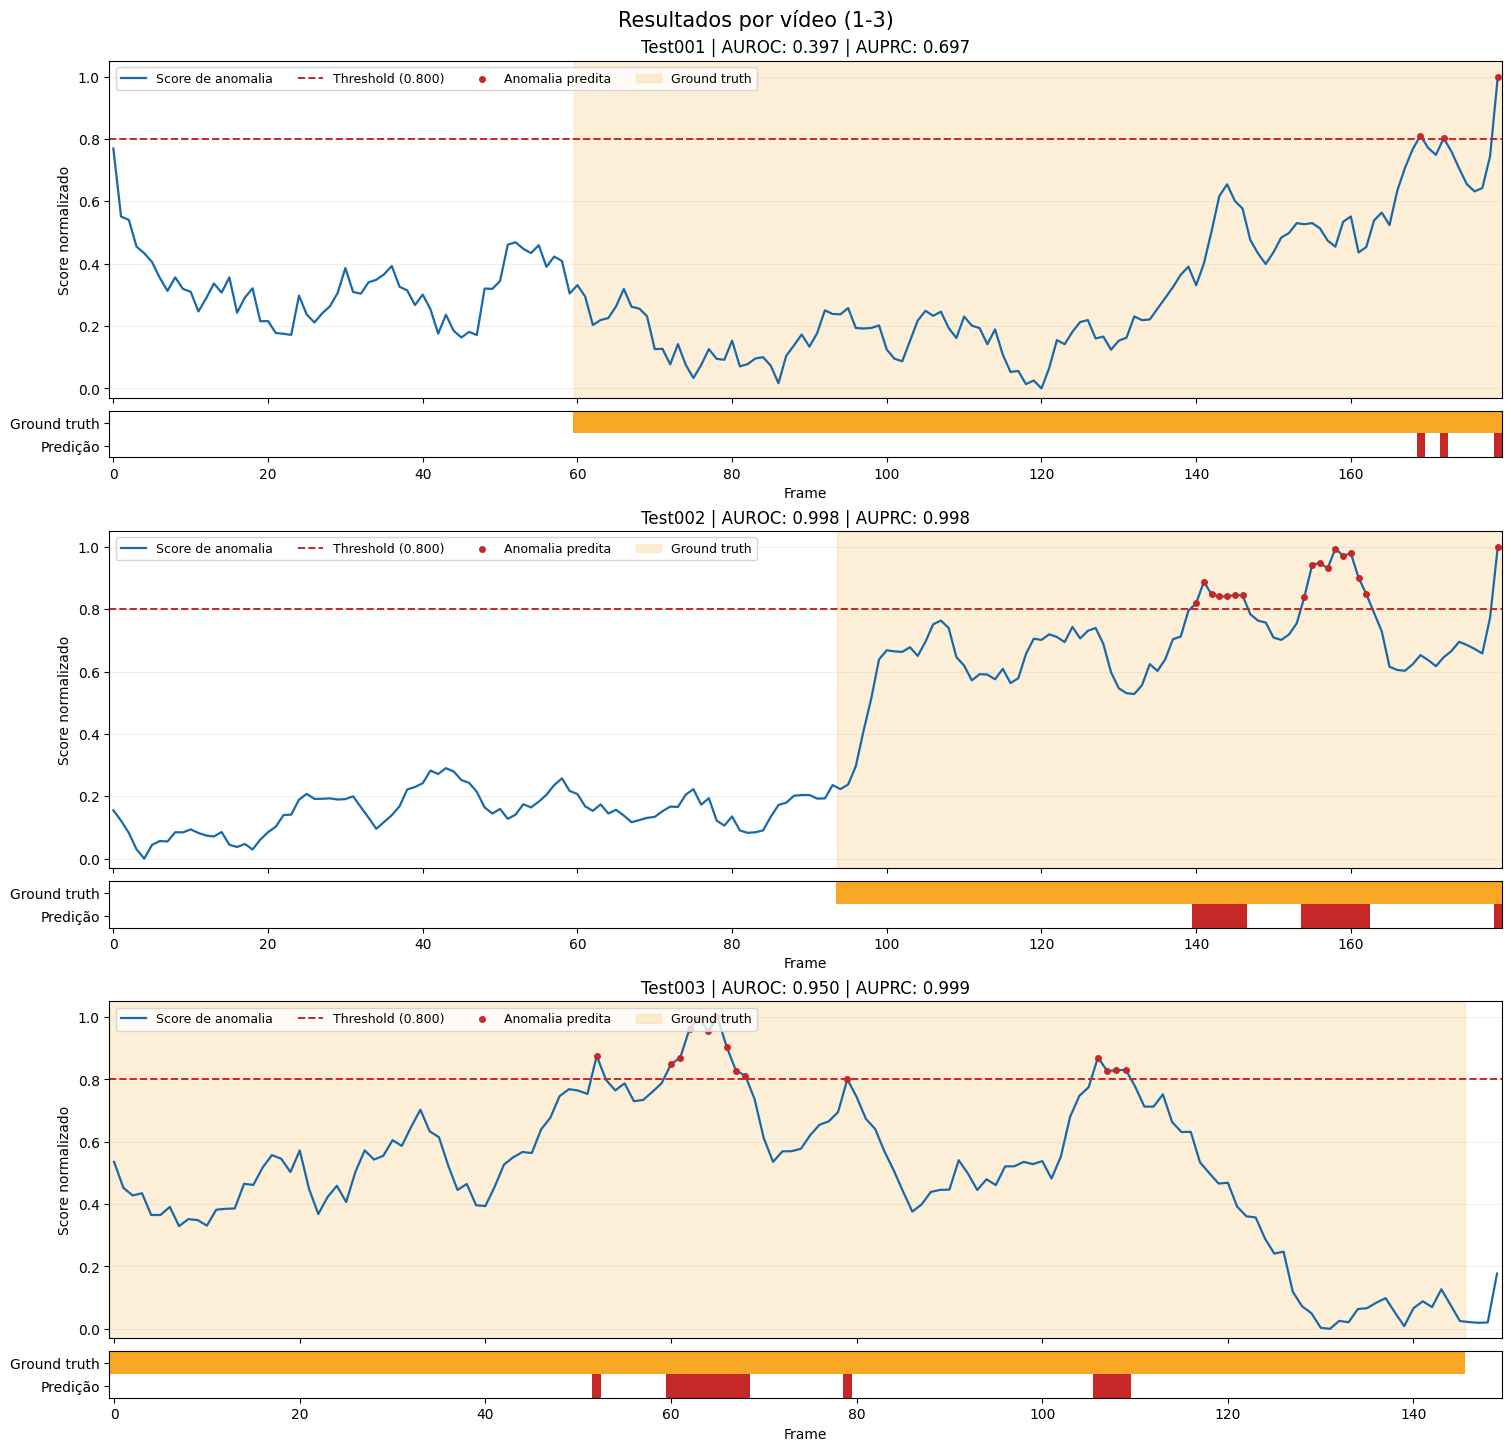

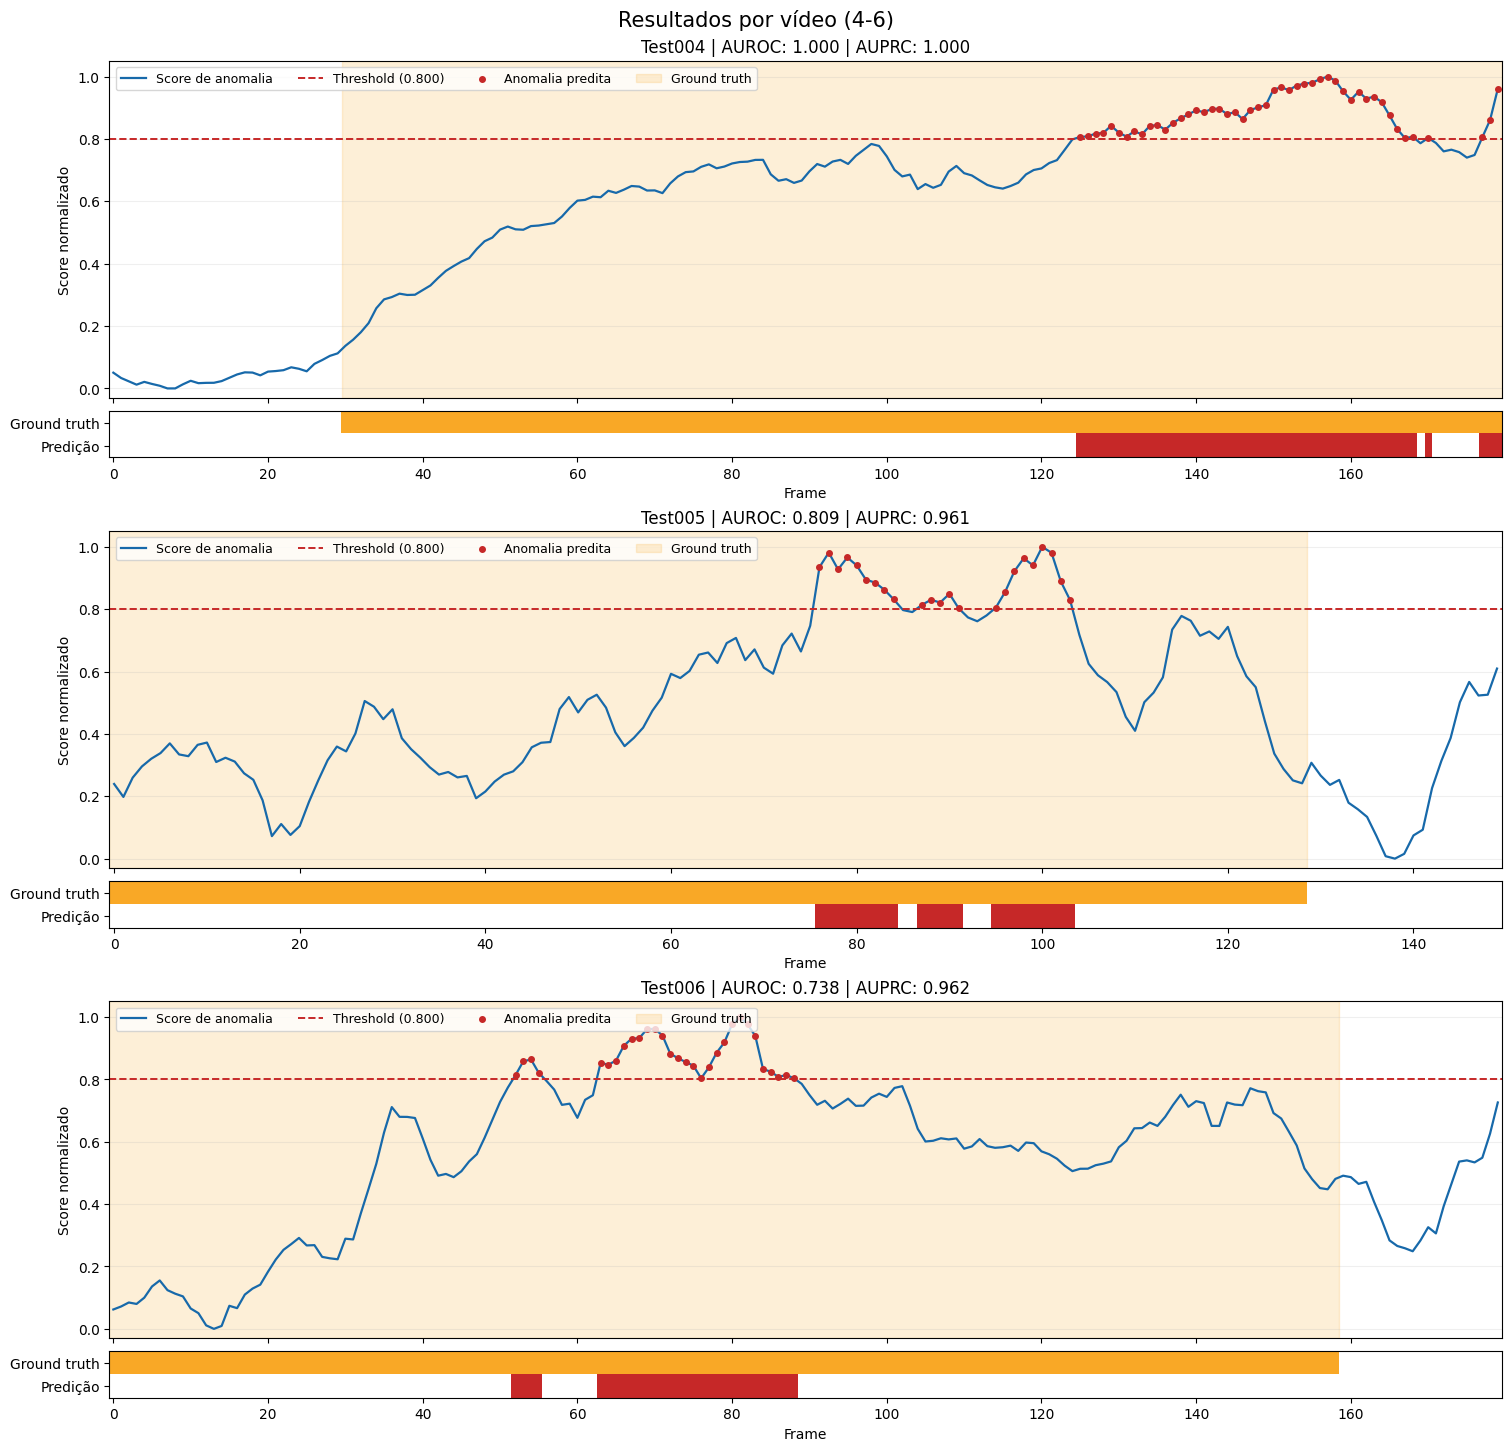

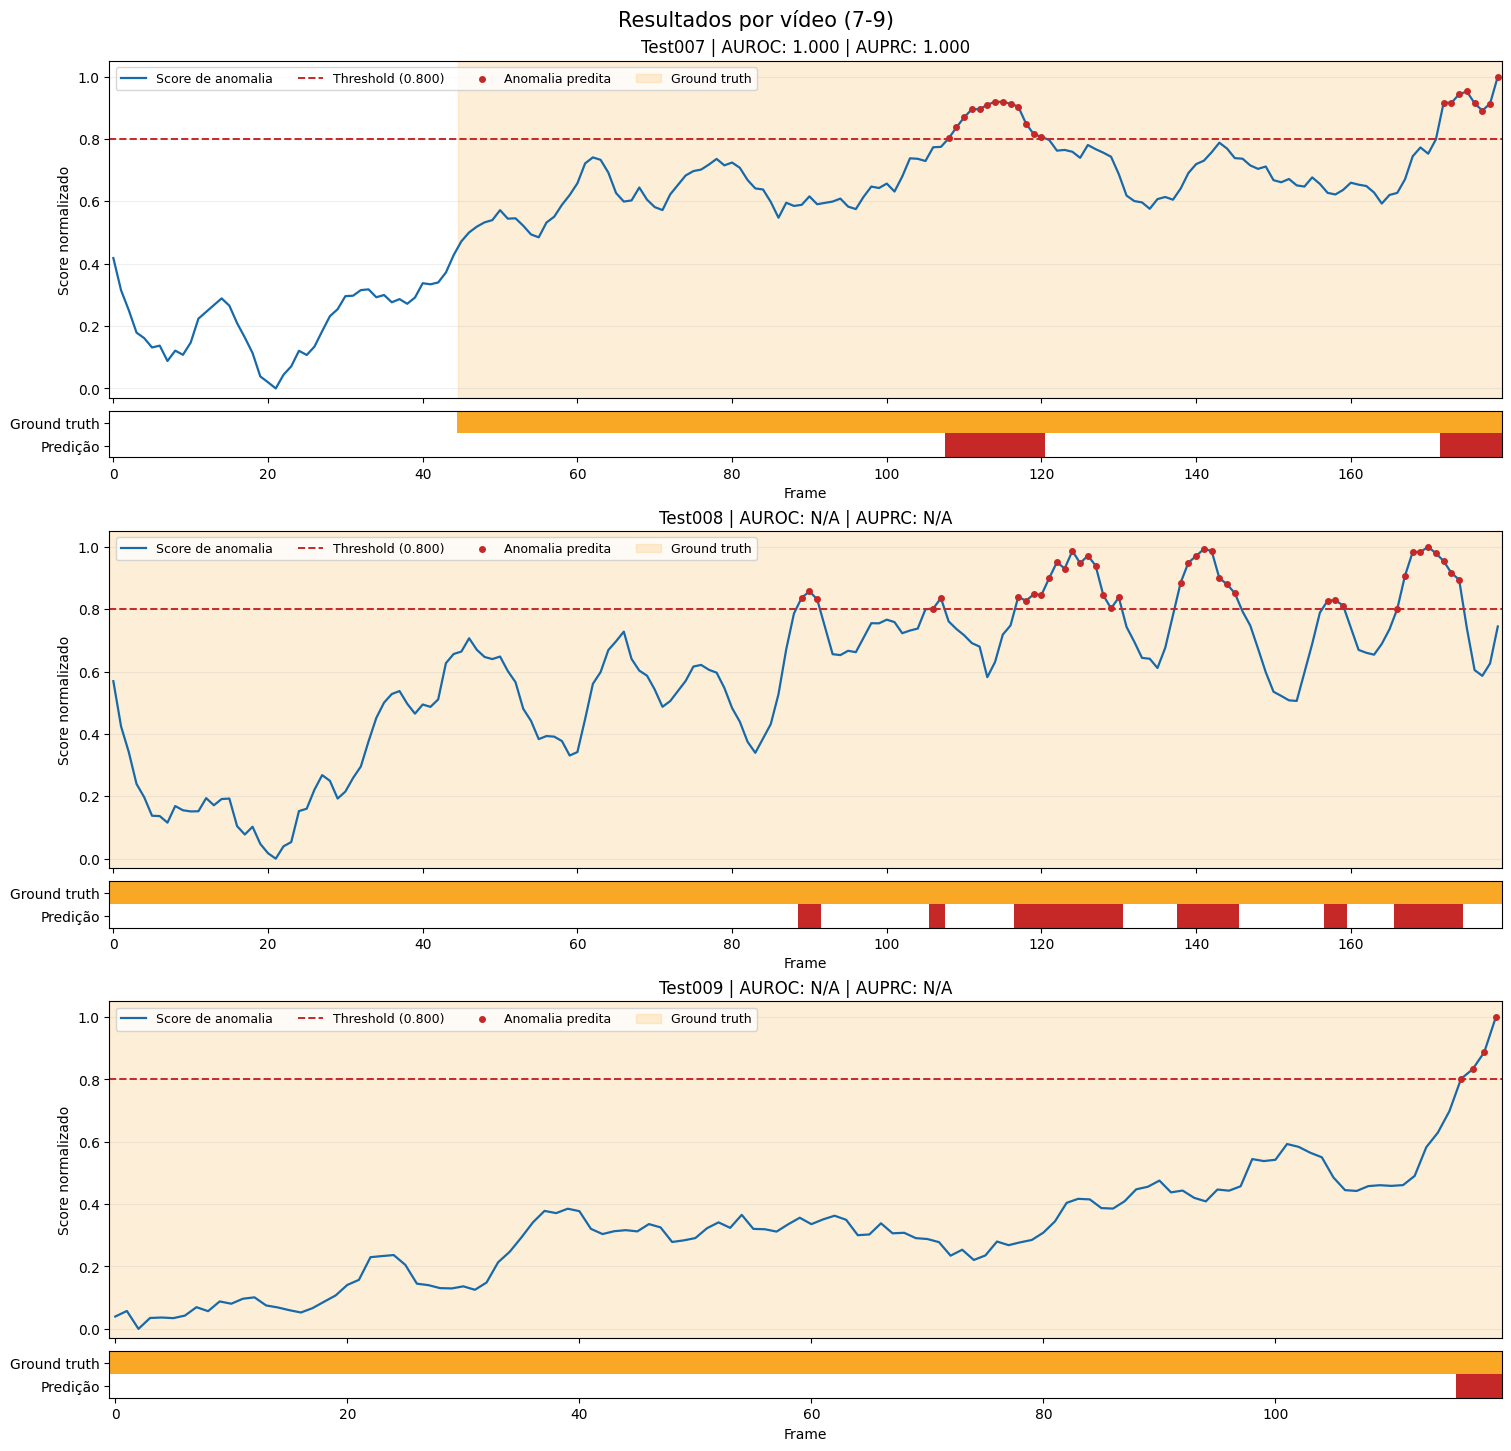

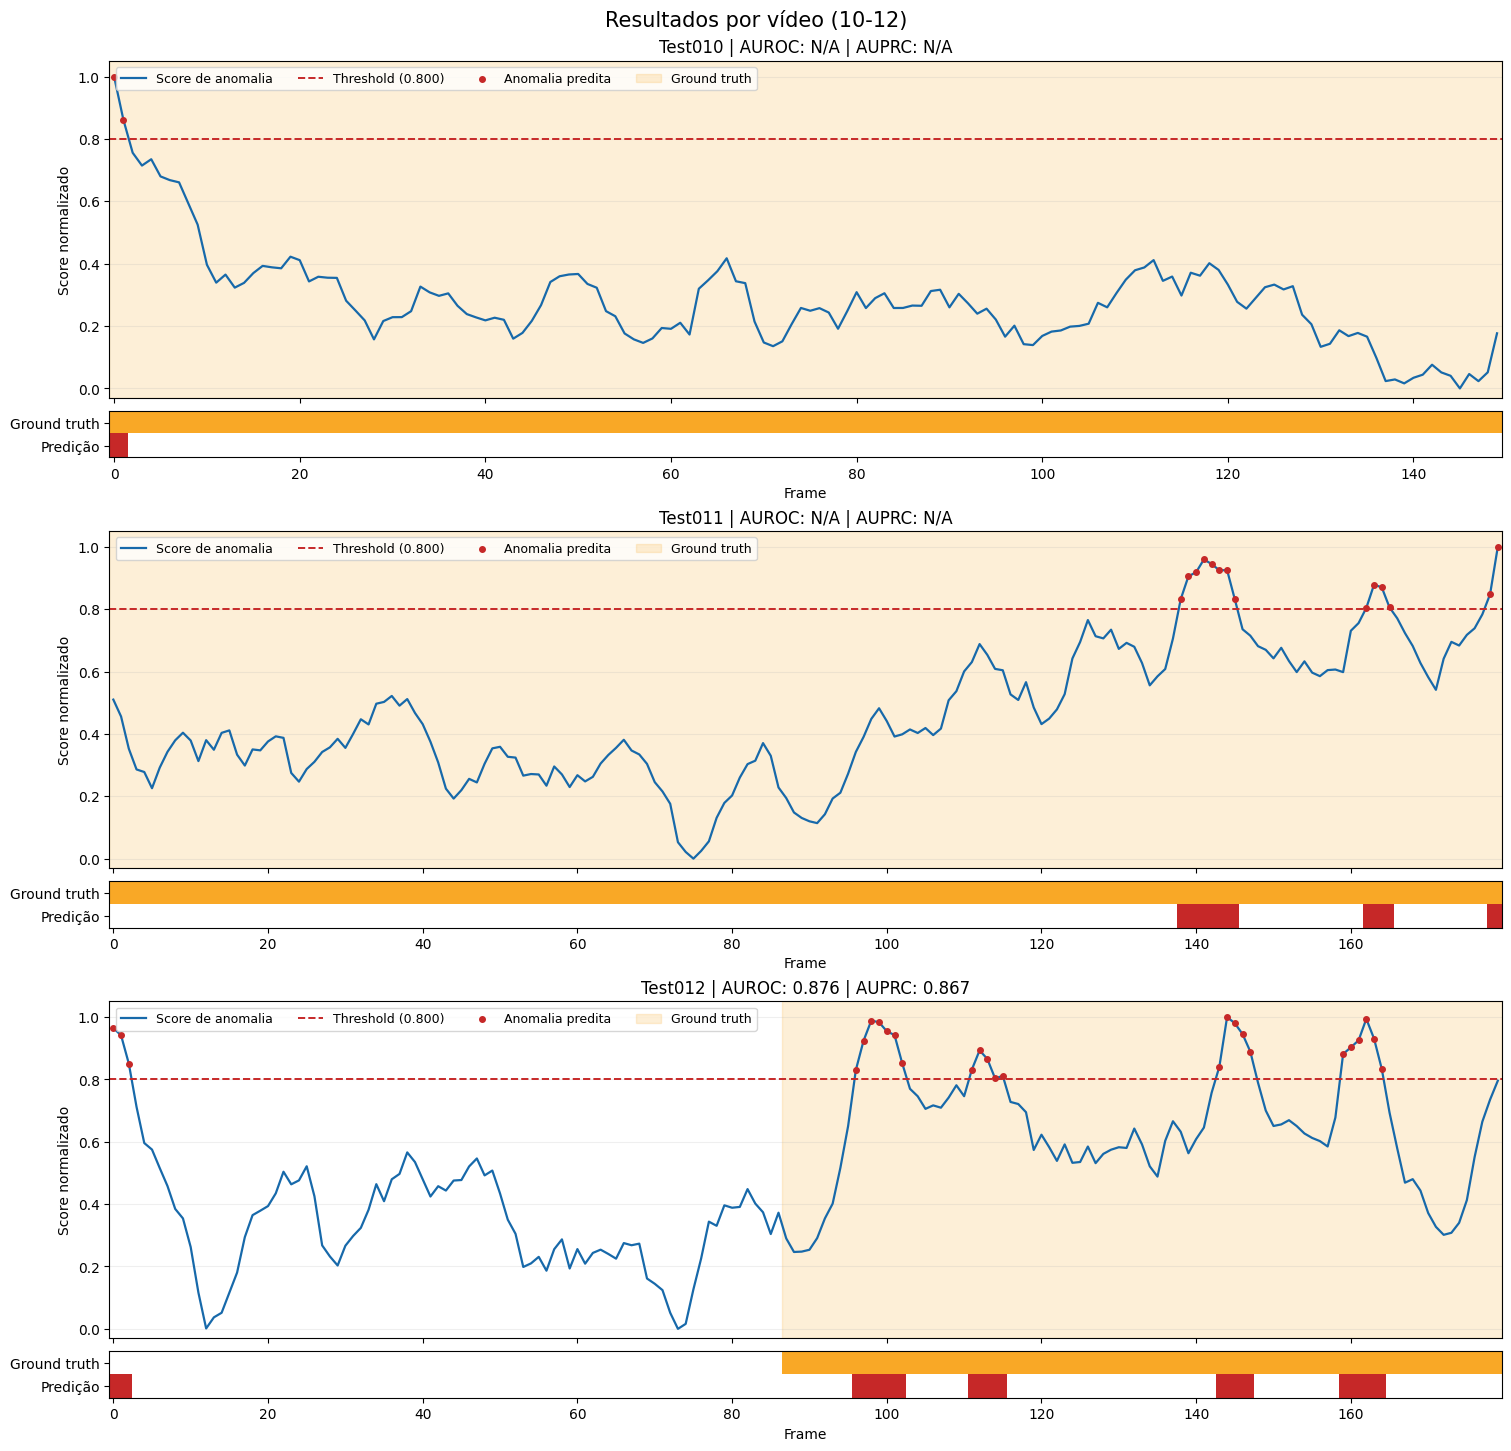

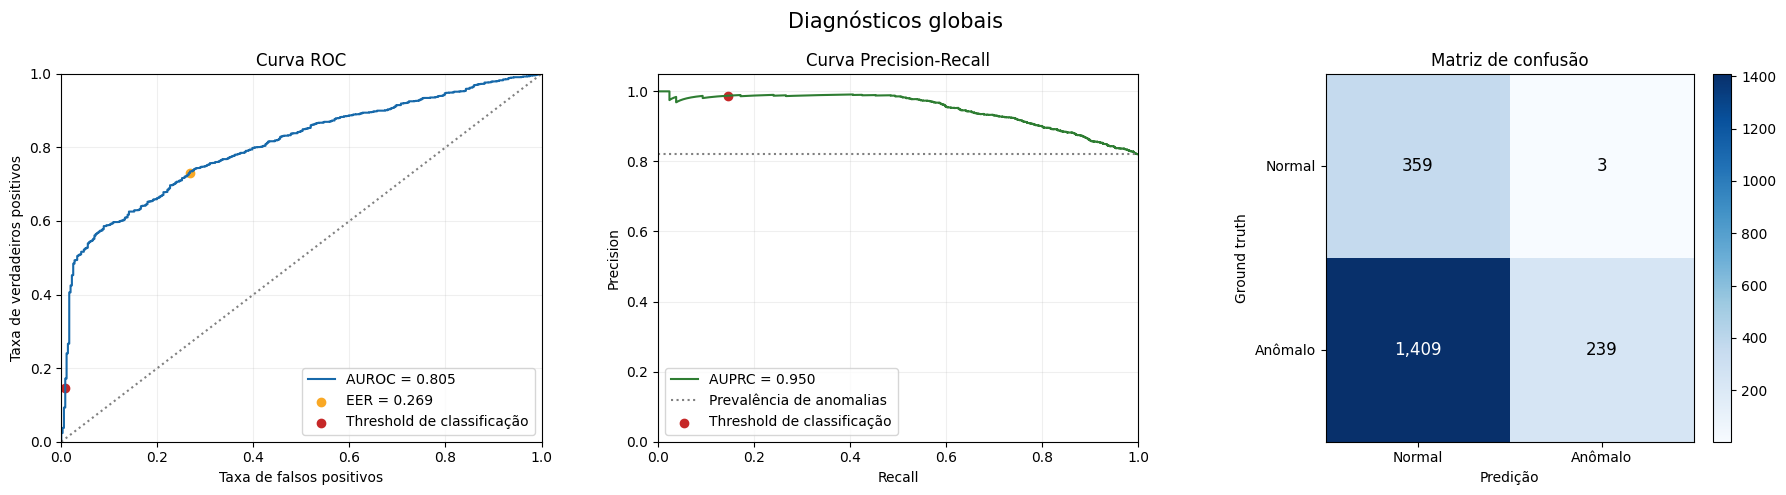

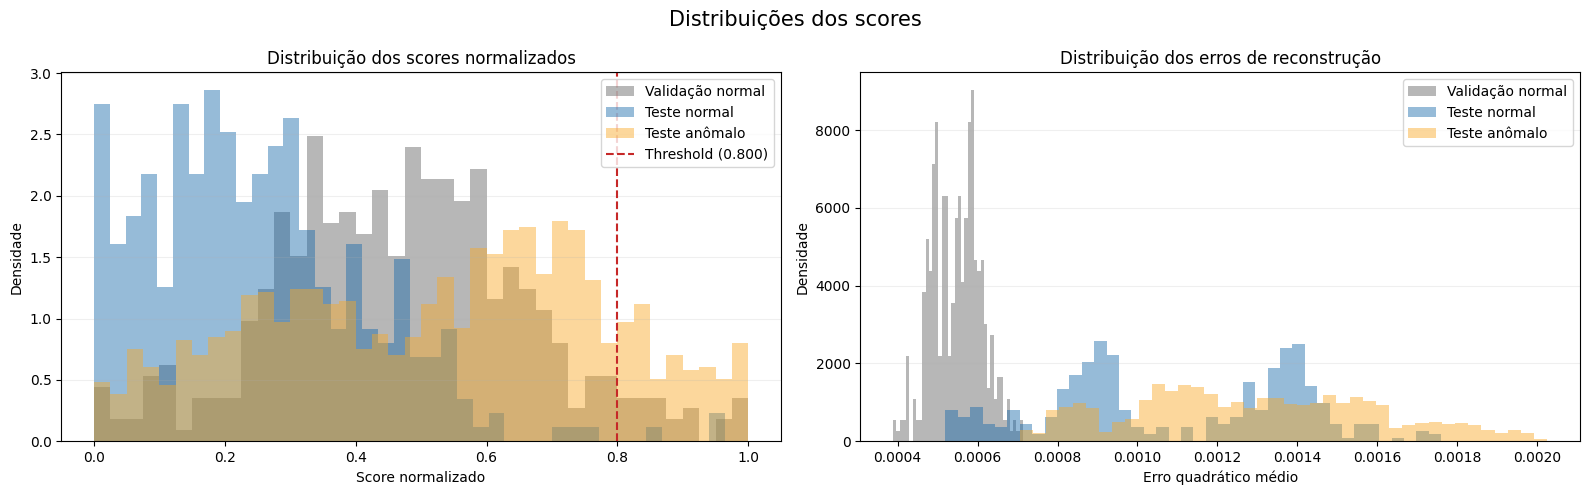

In [21]:
# Gera os gráficos por vídeo e os diagnósticos globais da avaliação
def get_anomaly_intervals(labels):
    padded_labels = np.pad(labels.astype(np.int8), (1, 1))
    label_changes = np.diff(padded_labels)
    start_indices = np.flatnonzero(label_changes == 1)
    end_indices = np.flatnonzero(label_changes == -1) - 1
    return zip(start_indices, end_indices)

def format_metric(value):
    return 'N/A' if np.isnan(value) else f'{value:.3f}'

def plot_video_results(results, threshold, videos_per_page=3):
    for page_start in range(0, len(results), videos_per_page):
        page_results = results[page_start:page_start + videos_per_page]
        height_ratios = [ratio for _ in page_results for ratio in (4, 0.55)]
        figure = plt.figure(figsize=(15, 4.8 * len(page_results)), constrained_layout=True)
        grid = figure.add_gridspec(len(page_results) * 2, 1, height_ratios=height_ratios)

        for index, video_result in enumerate(page_results):
            video_name = video_result['name']
            labels = video_result['labels']
            scores = video_result['normalized_scores']
            predictions = (scores >= threshold).astype(np.uint8)
            has_two_classes = np.unique(labels).size == 2
            video_auroc = (roc_auc_score(labels, scores) if has_two_classes else np.nan)
            video_auprc = (average_precision_score(labels, scores) if has_two_classes else np.nan)

            score_axis = figure.add_subplot(grid[index * 2])
            status_axis = figure.add_subplot(grid[index * 2 + 1], sharex=score_axis)

            score_axis.plot(scores, color='#1769aa', linewidth=1.6, label='Score de anomalia')
            score_axis.axhline(
                threshold,
                color='#c62828',
                linestyle='--',
                linewidth=1.4,
                label=f'Threshold ({threshold:.3f})'
            )

            predicted_frame_indices = np.flatnonzero(predictions)
            score_axis.scatter(
                predicted_frame_indices,
                scores[predicted_frame_indices],
                color='#c62828',
                s=16,
                zorder=3,
                label='Anomalia predita'
            )

            for interval_index, (start_index, end_index) in enumerate(
                get_anomaly_intervals(labels)
            ):
                score_axis.axvspan(
                    start_index - 0.5,
                    end_index + 0.5,
                    color='#f9a825',
                    alpha=0.18,
                    label='Ground truth' if interval_index == 0 else None
                )

            score_axis.set_title(
                f'{video_name} | '
                f'AUROC: {format_metric(video_auroc)} | '
                f'AUPRC: {format_metric(video_auprc)}'
            )
            score_axis.set_ylabel('Score normalizado')
            score_axis.set_ylim(-0.03, 1.05)
            score_axis.set_xlim(-0.5, len(labels) - 0.5)
            score_axis.grid(axis='y', alpha=0.2)
            score_axis.legend(loc='upper left', ncols=4, fontsize=9)
            score_axis.tick_params(labelbottom=False)

            status_image = np.ones((2, len(labels), 3), dtype=np.float32)
            status_image[0, labels.astype(bool)] = [0.98, 0.66, 0.15]
            status_image[1, predictions.astype(bool)] = [0.78, 0.16, 0.16]

            status_axis.imshow(
                status_image,
                aspect='auto',
                interpolation='nearest',
                extent=(-0.5, len(labels) - 0.5, 1.5, -0.5)
            )
            status_axis.set_yticks([0, 1], labels=['Ground truth', 'Predição'])
            status_axis.set_xlabel('Frame')

        page_end = page_start + len(page_results)
        figure.suptitle(f'Resultados por vídeo ({page_start + 1}-{page_end})', fontsize=15)
        plt.show()

def plot_global_diagnostics():
    precision_values, recall_values, _ = precision_recall_curve(
        ground_truth_labels,
        normalized_test_scores
    )
    confusion = confusion_matrix(ground_truth_labels, predicted_test_labels, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = (confusion.ravel())
    operating_false_positive_rate = false_positive / max(false_positive + true_negative, 1)
    operating_true_positive_rate = true_positive / max(true_positive + false_negative, 1)

    figure, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(
        false_positive_rates,
        true_positive_rates,
        color='#1769aa',
        label=f'AUROC = {auroc:.3f}'
    )
    axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':')
    axes[0].scatter(
        false_positive_rates[eer_index],
        true_positive_rates[eer_index],
        color='#f9a825',
        label=f'EER = {eer:.3f}'
    )
    axes[0].scatter(
        operating_false_positive_rate,
        operating_true_positive_rate,
        color='#c62828',
        label='Threshold de classificação'
    )
    axes[0].set(
        title='Curva ROC',
        xlabel='Taxa de falsos positivos',
        ylabel='Taxa de verdadeiros positivos',
        xlim=(0, 1),
        ylim=(0, 1)
    )
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].plot(recall_values, precision_values, color='#2e7d32', label=f'AUPRC = {auprc:.3f}')
    axes[1].axhline(
        ground_truth_labels.mean(),
        color='gray',
        linestyle=':',
        label='Prevalência de anomalias'
    )
    axes[1].scatter(recall, precision, color='#c62828', label='Threshold de classificação')
    axes[1].set(
        title='Curva Precision-Recall',
        xlabel='Recall',
        ylabel='Precision',
        xlim=(0, 1),
        ylim=(0, 1.05)
    )
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    image = axes[2].imshow(confusion, cmap='Blues')
    for row_index in range(2):
        for column_index in range(2):
            cell_value = confusion[row_index, column_index]
            axes[2].text(
                column_index,
                row_index,
                f'{cell_value:,}',
                ha='center',
                va='center',
                color=(
                    'white'
                    if cell_value > confusion.max() / 2
                    else 'black'
                ),
                fontsize=12
            )
    axes[2].set(
        title='Matriz de confusão',
        xlabel='Predição',
        ylabel='Ground truth',
        xticks=[0, 1],
        yticks=[0, 1]
    )
    axes[2].set_xticklabels(['Normal', 'Anômalo'])
    axes[2].set_yticklabels(['Normal', 'Anômalo'])
    figure.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)

    figure.suptitle('Diagnósticos globais', fontsize=15)
    plt.tight_layout()
    plt.show()

def plot_score_distributions():
    test_reconstruction_errors = np.concatenate([
        result['reconstruction_errors']
        for result in video_results
    ])

    figure, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(
        validation_normalized_scores,
        bins=40,
        density=True,
        alpha=0.45,
        color='#616161',
        label='Validação normal'
    )
    axes[0].hist(
        normalized_test_scores[ground_truth_labels == 0],
        bins=40,
        density=True,
        alpha=0.45,
        color='#1769aa',
        label='Teste normal'
    )
    axes[0].hist(
        normalized_test_scores[ground_truth_labels == 1],
        bins=40,
        density=True,
        alpha=0.45,
        color='#f9a825',
        label='Teste anômalo'
    )
    axes[0].axvline(
        classification_threshold,
        color='#c62828',
        linestyle='--',
        label=f'Threshold ({classification_threshold:.3f})'
    )
    axes[0].set(
        title='Distribuição dos scores normalizados',
        xlabel='Score normalizado',
        ylabel='Densidade'
    )
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.2)

    axes[1].hist(
        validation_reconstruction_errors,
        bins=40,
        density=True,
        alpha=0.45,
        color='#616161',
        label='Validação normal'
    )
    axes[1].hist(
        test_reconstruction_errors[ground_truth_labels == 0],
        bins=40,
        density=True,
        alpha=0.45,
        color='#1769aa',
        label='Teste normal'
    )
    axes[1].hist(
        test_reconstruction_errors[ground_truth_labels == 1],
        bins=40,
        density=True,
        alpha=0.45,
        color='#f9a825',
        label='Teste anômalo'
    )
    axes[1].set(
        title='Distribuição dos erros de reconstrução',
        xlabel='Erro quadrático médio',
        ylabel='Densidade'
    )
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.2)

    figure.suptitle('Distribuições dos scores', fontsize=15)
    plt.tight_layout()
    plt.show()

plot_video_results(video_results, classification_threshold)
plot_global_diagnostics()
plot_score_distributions()